# Low Orbit Validation: International Space Station (ECOSTRESS and EMIT)

Instruments on the International Space Station (ISS), such as the ECOSTRESS thermal radiometer and the EMIT imaging spectrometer, observe from a low (about 420 km), non-sun-synchronous orbit (51.6 deg inclination). Atmospheric drag lowers this orbit continually, and the station's engines raise it every few weeks (reboosts), so public two-line element (TLE) sets lose accuracy faster than for higher satellites. Because the orbit precesses relative to the Sun, the local time of the station's observations changes from day to day. This notebook compares TAT-C's predictions from one ISS TLE with the station's trajectory and with EMIT's scenes over the preceding 30 days, and asks:

1. **Orbit.** How does the accuracy of a propagated ISS TLE degrade in the days before its epoch, and how do reboosts affect it?
2. **Observations.** Does `collect_observations` predict EMIT's scenes, their times, and their solar geometry?

## Reference Data

* The ECOSTRESS Level 1B attitude and ephemeris product (ECO_L1B_ATT, version 2) records the station's position, velocity, and attitude (in the J2000 inertial frame, every second, with times in seconds since J2000 in Terrestrial Time) for each orbit; one orbit in four from 4 September to 4 October 2026 is downloaded (about 40 MB). Downloading requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package.
* The EMIT Level 1B radiance product (EMITL1BRAD, version 2) catalog (anonymous access) lists each scene acquired from 20 September to 2 October 2026 with its footprint, start and end times, and solar zenith angle.

Data are cached in a local `data/iss` directory. The ISS is modeled with a TLE from [CelesTrak](https://celestrak.org/) whose epoch is 4 October 2026, 12:43 UTC.

In [1]:
import concurrent.futures
import json
from datetime import datetime, timedelta, timezone
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from pyproj import Geod
from scipy.spatial.transform import Rotation
from shapely.geometry import Polygon
from skyfield.api import wgs84

from tatc import utils
from tatc.analysis import collect_observations
from tatc.constants import EARTH_MEAN_RADIUS, timescale
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Point, PointedInstrument, Satellite

DATA_DIR = Path("data") / "iss"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 9, 4, tzinfo=timezone.utc)
END = datetime(2026, 10, 4, 12, tzinfo=timezone.utc)
SCENES_START = datetime(2026, 9, 20, tzinfo=timezone.utc)
SCENES_END = datetime(2026, 10, 3, tzinfo=timezone.utc)
TLE = [
    "1 25544U 98067A   26277.53034530  .00003768  00000+0  77215-4 0  9996",
    "2 25544  51.6316 118.9662 0006881 221.7555 138.2909 15.48731752588700",
]
TLE_EPOCH = datetime(2026, 10, 4, 12, 43, 41, tzinfo=timezone.utc)
geod = Geod(ellps="WGS84")

attitude_files = sorted(DATA_DIR.glob("ECOv002_L1B_ATT_*.h5"))
if not attitude_files:
    import earthaccess

    earthaccess.login()
    results = earthaccess.search_data(short_name="ECO_L1B_ATT", version="002", temporal=(START.strftime("%Y-%m-%dT%H:%M:%SZ"), END.strftime("%Y-%m-%dT%H:%M:%SZ")))
    earthaccess.download(results[::4], str(DATA_DIR))
    attitude_files = sorted(DATA_DIR.glob("ECOv002_L1B_ATT_*.h5"))
frames, attitudes = [], []
for path in attitude_files:
    with h5py.File(path, "r") as f:
        frames.append(pd.DataFrame(np.c_[f["Ephemeris/time_j2000"][::30], f["Ephemeris/eci_position"][::30], f["Ephemeris/eci_velocity"][::30]], columns=["tt_j2000", "x", "y", "z", "vx", "vy", "vz"]))
        # attitude quaternions (scalar first, spacecraft to J2000), every 5 minutes
        attitudes.append(pd.DataFrame(np.c_[f["Attitude/time_j2000"][::300], f["Attitude/quaternion"][::300]], columns=["tt_j2000", "qw", "qx", "qy", "qz"]))
ephemeris = pd.concat(frames).drop_duplicates("tt_j2000").sort_values("tt_j2000").reset_index(drop=True)
times = timescale.tt_jd(2451545.0 + ephemeris.tt_j2000.to_numpy() / 86400)
ephemeris["time"] = pd.to_datetime(times.utc_datetime())

SCENES_FILE = DATA_DIR / f"emit_scenes_{SCENES_START:%Y%m%d}_{SCENES_END - timedelta(days=1):%Y%m%d}.json"
if not SCENES_FILE.exists():
    items, page = [], 1
    while True:
        response = requests.get(
            "https://cmr.earthdata.nasa.gov/search/granules.umm_json",
            params={"short_name": "EMITL1BRAD", "version": "002", "temporal": f"{SCENES_START:%Y-%m-%dT%H:%M:%SZ},{SCENES_END:%Y-%m-%dT%H:%M:%SZ}", "page_size": 2000, "page_num": page},
            timeout=300,
        )
        response.raise_for_status()
        batch = response.json()["items"]
        items += [
            {
                "id": item["umm"]["GranuleUR"],
                "start": item["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"],
                "end": item["umm"]["TemporalExtent"]["RangeDateTime"]["EndingDateTime"],
                "polygon": [[p["Longitude"], p["Latitude"]] for p in item["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]["GPolygons"][0]["Boundary"]["Points"]],
                "solar_zenith": float(next((a["Values"][0] for a in item["umm"].get("AdditionalAttributes", []) if a["Name"] == "SOLAR_ZENITH"), "nan")),
            }
            for item in batch
        ]
        if len(batch) < 2000:
            break
        page += 1
    SCENES_FILE.write_text(json.dumps(items))
scenes = pd.DataFrame(json.loads(SCENES_FILE.read_text()))
scenes["start"] = pd.to_datetime(scenes.start, utc=True)
scenes["end"] = pd.to_datetime(scenes.end, utc=True)
scenes["mid"] = scenes.start + (scenes.end - scenes.start) / 2
iss = GeneralPerturbationsOrbit.from_tle(TLE)
satrec = iss.elements[0].to_skyfield()
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})
pd.Series(
    {
        "ephemeris files (orbits)": len(attitude_files),
        "ephemeris samples (every 30 s)": len(ephemeris),
        "ephemeris period": f"{ephemeris.time.min():%Y-%m-%d %H:%M} to {ephemeris.time.max():%Y-%m-%d %H:%M}",
        "EMIT scenes": len(scenes),
    }
)

ephemeris files (orbits)                                           112
ephemeris samples (every 30 s)                                    4536
ephemeris period                  2026-09-03 23:03 to 2026-10-04 11:09
EMIT scenes                                                       3275
dtype: object

## Test 1: Orbit

The station's position is propagated from the TLE (SGP4) at the ephemeris times and compared with the recorded position in the station's along-track and cross-track directions.

In [2]:
tatc_position = satrec.at(times).position.m.T
recorded = ephemeris[["x", "y", "z"]].to_numpy()
velocity = ephemeris[["vx", "vy", "vz"]].to_numpy()
radial = recorded / np.linalg.norm(recorded, axis=1, keepdims=True)
normal = np.cross(recorded, velocity)
normal /= np.linalg.norm(normal, axis=1, keepdims=True)
along = np.cross(normal, radial)
difference = tatc_position - recorded
ephemeris["radial (km)"] = np.sum(difference * radial, axis=1) / 1e3
ephemeris["along-track (km)"] = np.sum(difference * along, axis=1) / 1e3
ephemeris["cross-track (km)"] = np.sum(difference * normal, axis=1) / 1e3
ephemeris["along-track (s)"] = ephemeris["along-track (km)"] * 1e3 / np.linalg.norm(velocity, axis=1)
ephemeris["days before TLE epoch"] = (pd.Timestamp(TLE_EPOCH) - ephemeris.time) / pd.Timedelta(days=1)
ephemeris["day"] = ephemeris.time.dt.floor("D")
table1 = ephemeris.groupby("day").agg(
    **{
        "days before TLE epoch": ("days before TLE epoch", "mean"),
        "along-track, median (km)": ("along-track (km)", "median"),
        "along-track, median (s)": ("along-track (s)", "median"),
        "cross-track, p95 |x| (km)": ("cross-track (km)", lambda x: x.abs().quantile(0.95)),
    }
)
table1.index = table1.index.strftime("%Y-%m-%d")
departure = ephemeris[ephemeris["along-track (km)"].abs() > 20].time.max()
print(f"last ephemeris time with an along-track offset above 20 km: {departure:%Y-%m-%d %H:%M} UTC")
table1.round(2)

last ephemeris time with an along-track offset above 20 km: 2026-09-25 13:11 UTC


,days before TLE epoch,"along-track, median (km)","along-track, median (s)","cross-track, p95 |x| (km)"
day,,,,
2026-09-03,30.55,4673.83,609.77,2.42
2026-09-04,30.03,4588.95,599.02,2.45
2026-09-05,29.10,4424.76,577.20,2.50
2026-09-06,28.09,4250.99,554.50,2.19
2026-09-07,27.10,4102.25,536.14,2.11
2026-09-08,26.03,3883.13,506.57,2.10
2026-09-09,25.02,3722.37,486.63,2.20
2026-09-10,23.99,3520.83,459.95,1.82
2026-09-11,23.03,3325.82,433.97,1.67


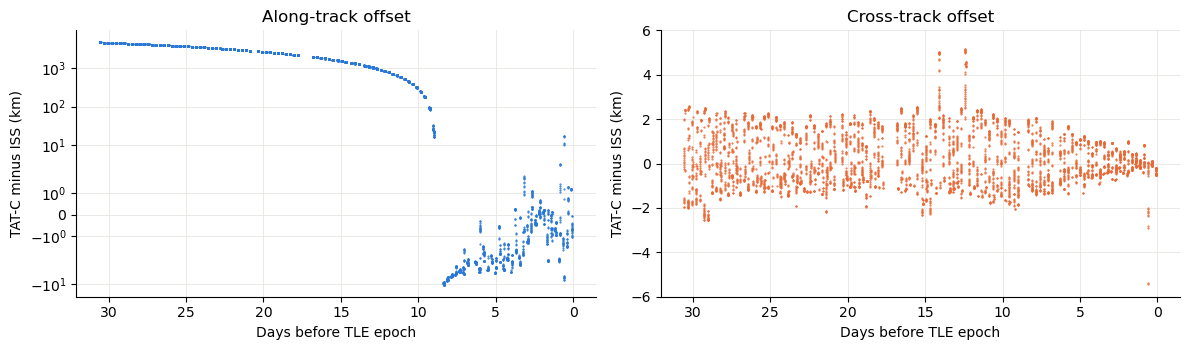

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(ephemeris["days before TLE epoch"], ephemeris["along-track (km)"], ".", ms=1, color=BLUE)
axes[0].set(xlabel="Days before TLE epoch", ylabel="TAT-C minus ISS (km)", title="Along-track offset", yscale="symlog")
axes[0].invert_xaxis()
axes[1].plot(ephemeris["days before TLE epoch"], ephemeris["cross-track (km)"], ".", ms=1, color=ORANGE)
axes[1].set(xlabel="Days before TLE epoch", ylabel="TAT-C minus ISS (km)", title="Cross-track offset", ylim=(-6, 6))
axes[1].invert_xaxis()
fig.tight_layout()
plt.show()

Back to 25 September, the propagated TLE follows the station to within 6 km along track (0.8 s) and about 2 km across track (95th percentile; 0.5 to 1 km in the last days). Before 25 September, 13:11 UTC, it departs abruptly: the station maneuvered then (a reboost), and the TLE, fitted to the trajectory after the maneuver, does not represent the orbit before it. The along-track offset grows by about 250 km (35 s) per day before the maneuver, to 1,100 km on 21 September and 4,250 km (610 s) on 6 September, while the cross-track offset stays within about 2.5 km. A single TLE therefore represents the station only back to its last maneuver.

## Test 2: Observations

EMIT is a pushbroom imaging spectrometer fixed to the station and pointed along the station's vertical axis. Its scenes are about 80 km wide; it is first modeled with an instrument whose field of regard spans the median scene width from the station's altitude, viewing nadir. For each scene, `collect_observations` (with `omit_solar=False`) is evaluated at the center of its footprint within 30 minutes of its midpoint time; the observation epoch is compared with the midpoint time, and the target's solar zenith angle with the scene's.

In [4]:
def scene_width(points):
    """Cross-track width (km) of a scene footprint: the shorter side of its quadrilateral."""
    lon, lat = np.array(points[:4]).T
    sides = geod.inv(lon, lat, np.roll(lon, -1), np.roll(lat, -1))[2] / 1e3
    return float(min((sides[0] + sides[2]) / 2, (sides[1] + sides[3]) / 2))


scenes["width (km)"] = scenes.polygon.map(scene_width)
scenes["center"] = scenes.polygon.map(lambda p: Polygon(p).centroid)
ALTITUDE = float(np.median(np.linalg.norm(recorded, axis=1))) - 6378137.0
emit = Instrument(name="EMIT", field_of_regard=utils.swath_width_to_field_of_regard(ALTITUDE, scenes["width (km)"].median() * 1e3))
satellite = Satellite(name="ISS", orbit=iss, instruments=[emit])


def observe(scene):
    """TAT-C's observation of a scene's center near its midpoint time."""
    point = Point(id=0, latitude=scene.center.y, longitude=scene.center.x)
    mid = scene.mid.floor("us").to_pydatetime()
    obs = collect_observations(point, satellite, mid - timedelta(minutes=30), mid + timedelta(minutes=30), omit_solar=False)
    if obs.empty:
        return {"id": scene.id, "observed": False}
    o = obs.iloc[np.argmin(np.abs((obs.epoch - scene.mid).dt.total_seconds()))]
    return {
        "id": scene.id,
        "observed": True,
        "epoch minus midpoint (s)": (o.epoch - scene.mid).total_seconds(),
        "solar zenith difference (deg)": (90 - o.solar_alt) - scene.solar_zenith,
        "local solar time (h)": o.solar_time,
    }


with concurrent.futures.ThreadPoolExecutor(8) as pool:
    observed = pd.DataFrame(list(pool.map(observe, scenes.itertuples())))
scenes = scenes.merge(observed, on="id")
scenes["days before TLE epoch"] = (pd.Timestamp(TLE_EPOCH) - scenes.mid) / pd.Timedelta(days=1)
scenes["bin"] = pd.cut(scenes["days before TLE epoch"], [1, 3, 5, 7, 9, 11, 13, 15])
table2 = scenes.groupby("bin", observed=True).agg(
    **{
        "scenes": ("id", "size"),
        "observed by TAT-C (%)": ("observed", lambda x: 100 * x.mean()),
        "epoch minus midpoint, median (s)": ("epoch minus midpoint (s)", "median"),
        "solar zenith difference, max |x| (deg)": ("solar zenith difference (deg)", lambda x: x.abs().max()),
        "local solar time, range (h)": ("local solar time (h)", lambda x: f"{x.min():.1f} to {x.max():.1f}"),
    }
)
print(f"median scene width {scenes['width (km)'].median():.1f} km; station altitude {ALTITUDE / 1e3:.0f} km; field of regard {emit.field_of_regard:.2f} deg")
table2.round(2)

median scene width 81.6 km; station altitude 419 km; field of regard 11.12 deg


,scenes,observed by TAT-C (%),"epoch minus midpoint, median (s)","solar zenith difference, max |x| (deg)","local solar time, range (h)"
bin,,,,,
"(1, 3]",280,100.00,-7.72,0.03,8.1 to 13.9
"(3, 5]",529,100.00,-8.63,0.03,9.0 to 17.3
"(5, 7]",412,100.00,-8.54,0.03,9.0 to 20.2
"(7, 9]",478,99.79,-8.07,0.05,9.2 to 21.7
"(9, 11]",550,100.00,-52.72,0.33,9.4 to 21.8
"(11, 13]",540,53.70,-93.89,0.39,9.8 to 20.3
"(13, 15]",486,0.41,-164.73,0.39,20.7 to 20.8


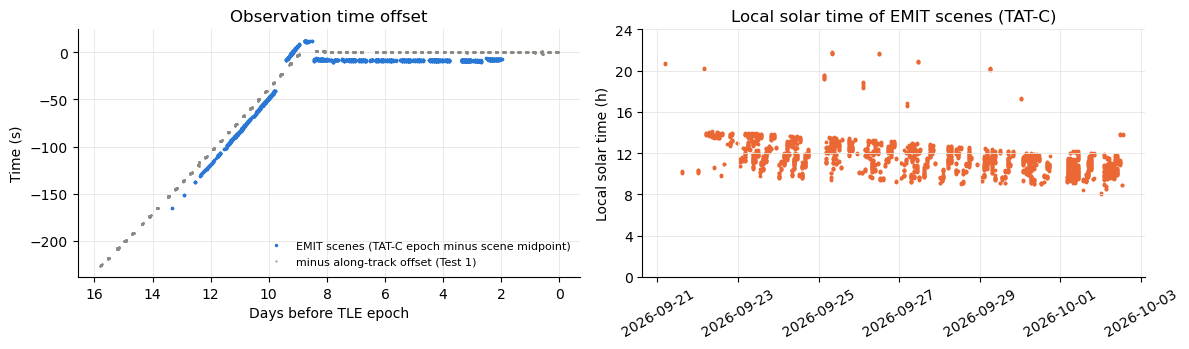

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(scenes["days before TLE epoch"], scenes["epoch minus midpoint (s)"], ".", ms=3, color=BLUE, label="EMIT scenes (TAT-C epoch minus scene midpoint)")
hourly = ephemeris[ephemeris["days before TLE epoch"] < 16]
axes[0].plot(hourly["days before TLE epoch"], -hourly["along-track (s)"], ".", ms=1, color=GRAY, label="minus along-track offset (Test 1)")
axes[0].set(xlabel="Days before TLE epoch", ylabel="Time (s)", title="Observation time offset")
axes[0].invert_xaxis()
axes[0].legend(frameon=False, fontsize=8)
axes[1].scatter(scenes.mid.dt.tz_convert(None), scenes["local solar time (h)"], s=3, color=ORANGE)
axes[1].set(ylabel="Local solar time (h)", title="Local solar time of EMIT scenes (TAT-C)", ylim=(0, 24), yticks=range(0, 25, 4))
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

TAT-C predicts every EMIT scene within 9 days of the TLE epoch (99.8 to 100%), but only half of those 11 to 13 days before it and almost none earlier, where the along-track error of the orbit before the maneuver exceeds the scenes' extent. Its solar zenith angles agree with the scenes' to within 0.05 deg within 9 days of the epoch (0.4 deg earlier, from the timing errors). The local solar time of the scenes drifts by about 20 minutes per day, from about 10:00 to 14:00 on 22 September to 8:00 to 12:00 on 2 October, as the station's orbit precesses relative to the Sun, with occasional scenes in the evening.

The observation epochs follow the orbit's along-track offset, except for a constant offset: where the orbit is accurate, TAT-C observes the scene centers 8.5 s (7.2 to 9.0 s) before the scenes' midpoint times, which is about 60 km along track.

The station does not fly level: its attitude, recorded with the ephemeris, is expressed relative to the local orbital frame (forward, cross-track, and nadir axes) as yaw, pitch, and roll angles. EMIT is then modeled as a rectangular `PointedInstrument` with the same cross-track field of view, tilted by the station's median pitch angle (positive pitch looks forward), and the observation epochs of the scenes are compared again.

In [6]:
attitude = pd.concat(attitudes).drop_duplicates("tt_j2000").sort_values("tt_j2000").reset_index(drop=True)
attitude_times = timescale.tt_jd(2451545.0 + attitude.tt_j2000.to_numpy() / 86400)
nearest = np.searchsorted(ephemeris.tt_j2000.to_numpy(), attitude.tt_j2000.to_numpy()).clip(0, len(ephemeris) - 1)
r_eci, v_eci = recorded[nearest], velocity[nearest]
nadir = -r_eci / np.linalg.norm(r_eci, axis=1, keepdims=True)
cross = -np.cross(r_eci, v_eci)
cross /= np.linalg.norm(cross, axis=1, keepdims=True)
forward = np.cross(cross, nadir)
orbital = np.stack([forward, cross, nadir], axis=1)  # rows: orbital frame axes in J2000
body = Rotation.from_quat(attitude[["qx", "qy", "qz", "qw"]].to_numpy()).as_matrix()  # columns: body axes in J2000
angles = Rotation.from_matrix(orbital @ body).as_euler("ZYX", degrees=True)
attitude["yaw (deg)"], attitude["pitch (deg)"], attitude["roll (deg)"] = angles.T
attitude["time"] = pd.to_datetime(attitude_times.utc_datetime())
in_scenes = attitude[(attitude.time >= pd.Timestamp(SCENES_START)) & (attitude.time < pd.Timestamp(SCENES_END))]
PITCH = float(in_scenes["pitch (deg)"].median())
print(f"station attitude, {SCENES_START:%d %b} to {SCENES_END - timedelta(days=1):%d %b} (median and 5th to 95th percentiles):")
in_scenes[["yaw (deg)", "pitch (deg)", "roll (deg)"]].describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%"]].round(2)

station attitude, 20 Sep to 02 Oct (median and 5th to 95th percentiles):


,yaw (deg),pitch (deg),roll (deg)
5%,-4.11,-9.43,0.61
50%,-3.99,-8.89,0.86
95%,-3.64,-7.60,1.07


In [7]:
emit_pitched = PointedInstrument(name="EMIT", cross_track_field_of_view=emit.field_of_regard, along_track_field_of_view=1, pitch_angle=PITCH, is_rectangular=True)
pitched_satellite = Satellite(name="ISS", orbit=iss, instruments=[emit_pitched])


def observe_pitched(scene):
    """Observation epoch of a scene's center by the pitched instrument, relative to its midpoint time."""
    point = Point(id=0, latitude=scene.center.y, longitude=scene.center.x)
    mid = scene.mid.floor("us").to_pydatetime()
    obs = collect_observations(point, pitched_satellite, mid - timedelta(minutes=30), mid + timedelta(minutes=30))
    if obs.empty:
        return np.nan
    offsets = (obs.epoch - scene.mid).dt.total_seconds().to_numpy()
    return float(offsets[np.argmin(np.abs(offsets))])


recent = scenes[scenes["days before TLE epoch"] < 9]
with concurrent.futures.ThreadPoolExecutor(8) as pool:
    pitched_offsets = np.array(list(pool.map(observe_pitched, recent.itertuples())))
pd.DataFrame(
    {
        "nadir instrument": recent["epoch minus midpoint (s)"].describe(percentiles=[0.05, 0.5, 0.95]),
        f"instrument pitched {PITCH:.1f} deg": pd.Series(pitched_offsets).describe(percentiles=[0.05, 0.5, 0.95]),
    }
).loc[["count", "5%", "50%", "95%"]].round(2).rename(index=lambda i: f"epoch minus midpoint, {i} (s)" if i != "count" else "scenes observed (within 9 days of the TLE epoch)")

,nadir instrument,instrument pitched -8.9 deg
scenes observed (within 9 days of the TLE epoch),1698.00,1698.00
"epoch minus midpoint, 5% (s)",-9.04,0.65
"epoch minus midpoint, 50% (s)",-8.47,1.22
"epoch minus midpoint, 95% (s)",-7.18,2.51


The station flies pitched by -8.9 deg (between -9.4 and -7.6 deg) relative to its local orbital frame, with a yaw of -4 deg and a roll of 0.9 deg, as the station's attitude is chosen to minimize the torques on it. EMIT, fixed to the station, thus views about 9 deg aft of nadir. With this pitch, TAT-C's observation epochs agree with the scenes' midpoint times to within 1.2 s (median; 0.7 to 2.5 s), instead of 8.5 s, the remainder reflecting the variations of the station's attitude and EMIT's alignment.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit | TLE within 6 km along track and 2 km across track back to the station's last maneuver (9 days before the TLE epoch); along-track errors grow by about 250 km per day before it |
| 2. Observations | all EMIT scenes predicted within 9 days of the TLE epoch, with solar zenith angles within 0.05 deg; observation epochs within 1.2 s (median) when EMIT is modeled with the station's 8.9 deg pitch, 8.5 s when viewing nadir |

**Orbit.** A TLE propagated by SGP4 represents the ISS's low orbit well (a few kilometers) until the station's last maneuver, but not before it: the station is reboosted every few weeks, and a TLE describes the orbit only since the last reboost. Analyses of past ISS observations need TLEs that bracket the period (a multi-element `GeneralPerturbationsOrbit`), and predictions for the future are limited by the next maneuver and by drag.

**Observations.** TAT-C predicts the scenes of an ISS instrument and their solar geometry, including the drift of local solar time of a precessing orbit. Instruments fixed to the station view along the station's axes rather than nadir: the station's attitude (here, a pitch of about 9 deg) shifts their observations along track and can be modeled with the pitch (and roll) angles of a `PointedInstrument`.